## Partie C : Implémentation Numérique par Méthodes de Monte-Carlo
Dans cette partie, nous allons évaluer les prix et les sensibilités (le "Grec" Delta $\Delta$) pour deux options asiatiques dans le cadre du modèle de Black-Scholes.
Les paramètres fournis par l'énoncé sont :
- Prix initial : $x = 100$
- Taux sans risque : $r = 0.03$ ($3\%$)
- Volatilité : $\sigma = 0.20$ ($20\%$)
- Maturité : $T = 1$ an

La dynamique de l'actif sous la probabilité risque-neutre est : $$dX_t^x = r X_t^x dt + \sigma X_t^x dB_t$$

Dont la solution explicite nous permet de simuler exactement les trajectoires (sans erreur de discrétisation d'Euler) :$$X_t^x = x \exp\left( \left(r - \frac{\sigma^2}{2}\right)t + \sigma B_t \right)$$L'intégrale de la trajectoire, nécessaire pour les options asiatiques, sera approchée par la somme de Riemann définie dans l'énoncé :$$\int_0^T X_s^x ds \approx \frac{T}{M} \sum_{k=0}^M X_{\frac{kT}{M}}$$Nous testerons pour $M \in \{50, 150, 250\}$ comme demandé.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

# Paramètres globaux (valeurs de l'énoncé)
x = 100.0
r = 0.03
sigma = 0.20
T = 1.0
K1 = 100.0
K2 = 110.0

def trajectories_simulation(N, M):
    """
    Simule N trajectoires du modèle de Black-Scholes discrétisées en M pas de temps.
    Retourne la matrice des trajectoires X (N x M+1) et l'approximation de l'intégrale (N).
    """
    
    dt = T / M

    # Génération des accroissements aléatoires
    Z = np.random.randn(N, M)
    W = np.sqrt(dt) * Z  #Mise à l'échelle temporelle
    
    # Construction du brownien avec les accroissements
    B = np.hstack((np.zeros((N, 1)), np.cumsum(W, axis=1)))
    
    # Grille de temps
    t = np.linspace(0, T, M + 1)
    
    # Simulation des trajectoires avec la formule de la dynamique de Black-Scholes
    X = x * np.exp((r - 0.5 * sigma**2) * t + sigma * B)
    
    # Approximation de l'intégrale avec somme de Riemann
    int_X = (T / M) * np.sum(X, axis=1)
    
    B_t1 = B[:, 1]
    
    return X, int_X, B_t1

### Question a 
Nous devons pricer deux options asiatiques :
- Un Call Asiatique de payoff : $\Phi_1 = \left( \int_0^T X_s^x ds - K_1 \right)_+$ 
- Une Option Digitale Asiatique de payoff : $\Phi_2 = \mathbf{1}_{\left\{ K_1 < \int_0^T X_s^x ds < K_2 \right\}}$  

L'estimateur de Monte-Carlo pour le prix est donné par la moyenne empirique des payoffs actualisés :$$\hat{P}_N = \frac{1}{N} \sum_{j=1}^N e^{-rT} \Phi^{(j)}$$La variance empirique de l'estimateur est $V_N = \frac{1}{N-1} \sum_{j=1}^N \left( e^{-rT} \Phi^{(j)} - \hat{P}_N \right)^2$. L'intervalle de confiance asymptotique à $95\%$ est obtenu via le Théorème Central Limite :$$IC_{95\%} = \left[ \hat{P}_N - 1.96 \frac{\sqrt{V_N}}{\sqrt{N}} , \hat{P}_N + 1.96 \frac{\sqrt{V_N}}{\sqrt{N}} \right]$$Nous étudierons la convergence pour $N$ allant de $1000$ à $51000$ avec un pas de $2000$, ce sont les valeurs données pour exemple dans le projet.


--- Résultats pour M = 50 pas de discrétisation ---
N = 51000 simulations :
Call Asiatique     : Prix = 6.4832, Variance = 72.7786, IC 95% = [6.4092, 6.5573]
Digitale Asiatique : Prix = 0.3074, Variance = 0.2038, IC 95% = [0.3035, 0.3113]

--- Résultats pour M = 150 pas de discrétisation ---
N = 51000 simulations :
Call Asiatique     : Prix = 5.7217, Variance = 64.3403, IC 95% = [5.6521, 5.7913]
Digitale Asiatique : Prix = 0.2954, Variance = 0.1994, IC 95% = [0.2915, 0.2993]

--- Résultats pour M = 250 pas de discrétisation ---
N = 51000 simulations :
Call Asiatique     : Prix = 5.4353, Variance = 61.4470, IC 95% = [5.3673, 5.5033]
Digitale Asiatique : Prix = 0.2950, Variance = 0.1992, IC 95% = [0.2911, 0.2988]


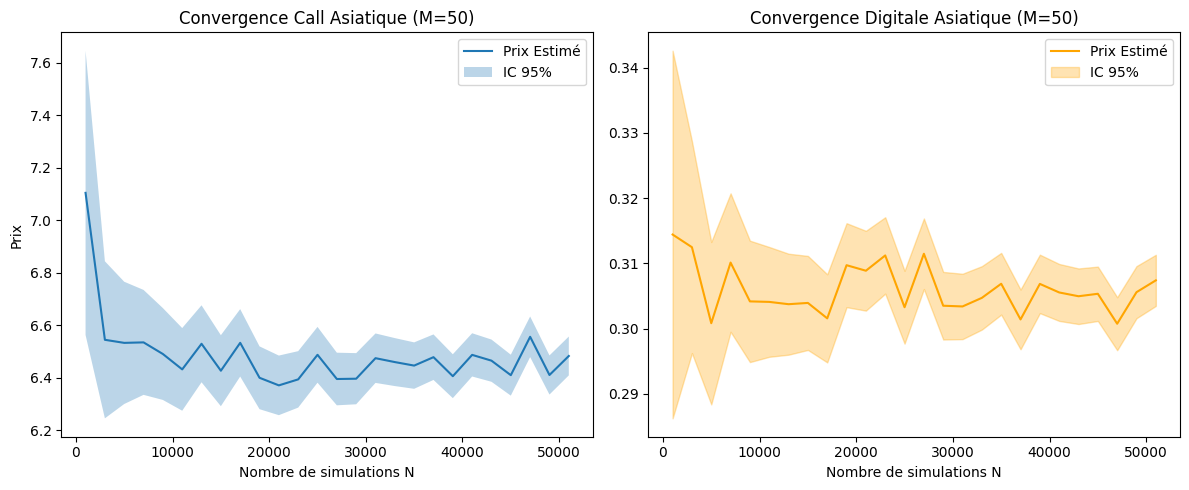

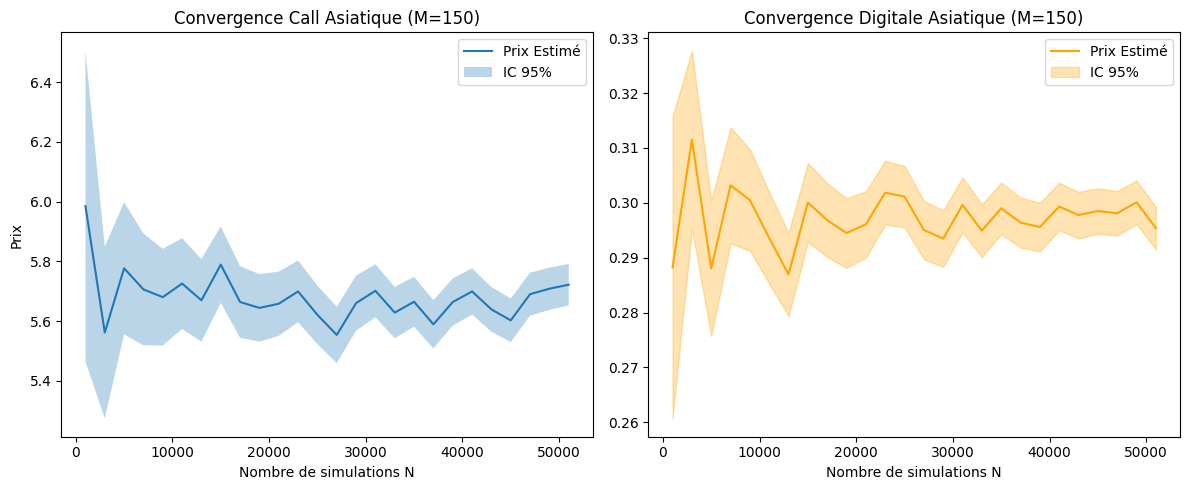

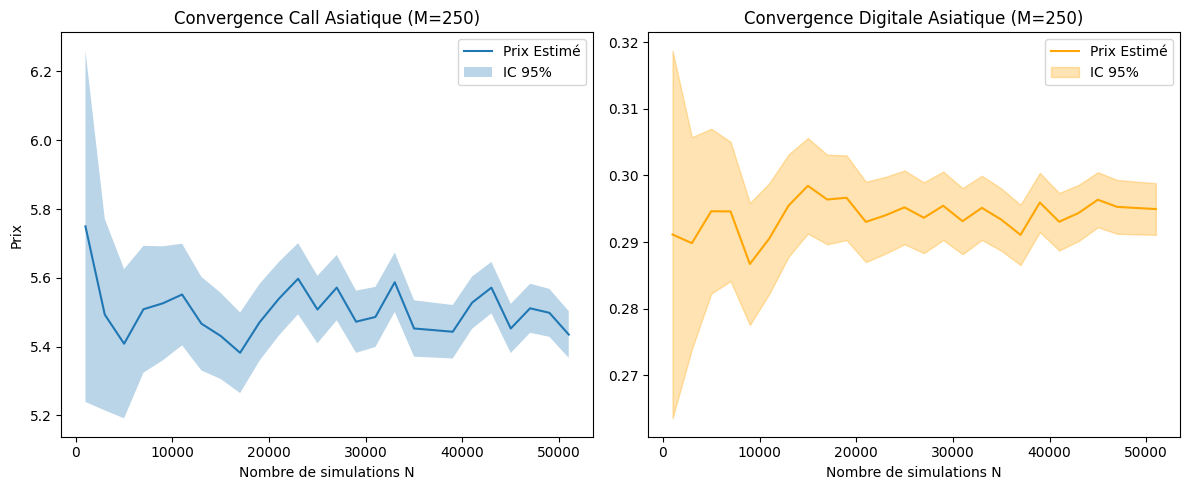

In [5]:
def payoffs(int_X):
    """Calcule les payoffs actualisés pour call et digit."""
    payoff_call = np.maximum(int_X - K1, 0) * np.exp(-r * T)
    payoff_digitale = ((int_X > K1) & (int_X < K2)).astype(float) * np.exp(-r * T)
    return payoff_call, payoff_digitale

#Valeurs des simulations (comme demandé dans l'énoncé)
N_values = np.arange(1000, 51001, 2000)
M_values = [50, 150, 250]

# Dictionnaires pour les plots futurs
results_prix = {M: {'call': [], 'digitale': [], 'ic_call': [], 'ic_digitale': []} for M in M_values}

for M in M_values:
    print(f"\n--- Résultats pour M = {M} pas de discrétisation ---")
    for N in N_values:
        X, int_X, _ = trajectories_simulation(N, M)
        p_call, p_dig = payoffs(int_X)
        
        # Moyennes
        mean_call, mean_dig = np.mean(p_call), np.mean(p_dig)

        # Variances empiriques
        var_call, var_dig = np.var(p_call, ddof=1), np.var(p_dig, ddof=1)

        # Intervalle de confiance à 95%
        hw_call = 1.96 * np.sqrt(var_call / N)
        hw_dig = 1.96 * np.sqrt(var_dig / N)
        
        results_prix[M]['call'].append(mean_call)
        results_prix[M]['digitale'].append(mean_dig)
        results_prix[M]['ic_call'].append(hw_call)
        results_prix[M]['ic_digitale'].append(hw_dig)
        
        # On affiche uniquement le résultat pour le plus grand N
        if N == N_values[-1]:
            print(f"N = {N} simulations :")
            print(f"Call Asiatique     : Prix = {mean_call:.4f}, Variance = {var_call:.4f}, IC 95% = [{mean_call-hw_call:.4f}, {mean_call+hw_call:.4f}]")
            print(f"Digitale Asiatique : Prix = {mean_dig:.4f}, Variance = {var_dig:.4f}, IC 95% = [{mean_dig-hw_dig:.4f}, {mean_dig+hw_dig:.4f}]")

# Graphiques de convergence pour tous les M différents
for M_plot in M_values:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(N_values, results_prix[M_plot]['call'], label='Prix Estimé')
    plt.fill_between(N_values, 
                     np.array(results_prix[M_plot]['call']) - np.array(results_prix[M_plot]['ic_call']), 
                     np.array(results_prix[M_plot]['call']) + np.array(results_prix[M_plot]['ic_call']), 
                     alpha=0.3, label='IC 95%')
    plt.title(f'Convergence Call Asiatique (M={M_plot})')
    plt.xlabel('Nombre de simulations N')
    plt.ylabel('Prix')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(N_values, results_prix[M_plot]['digitale'], label='Prix Estimé', color='orange')
    plt.fill_between(N_values, 
                     np.array(results_prix[M_plot]['digitale']) - np.array(results_prix[M_plot]['ic_digitale']), 
                     np.array(results_prix[M_plot]['digitale']) + np.array(results_prix[M_plot]['ic_digitale']), 
                     color='orange', alpha=0.3, label='IC 95%')
    plt.title(f'Convergence Digitale Asiatique (M={M_plot})')
    plt.xlabel('Nombre de simulations N')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

### Question b

La méthode des différences finies permet d'approximer la dérivée de la fonction de prix en déplacant les points de départs de $h$ :$$\Delta_{DF}(x) \approx \frac{P(x+h) - P(x-h)}{2h}$$

Dans le modèle de Black-Scholes, la trajectoire $X$ est purement proportionnelle à $x$. Ainsi, modifier la condition initiale revient simplement à redimensionner l'intégrale :$$\int_0^T X_s^{x \pm h} ds = \frac{x \pm h}{x} \int_0^T X_s^x ds$$Nous testerons l'impact du pas $h$ sur la variance.

In [6]:
def delta_differences_finies(int_X, h_values):
    N = len(int_X)
    resultats = {}
    
    for h in h_values:
        # Trajectoires modifiés pour la DF
        int_X_up = ((x + h) / x) * int_X
        int_X_down = ((x - h) / x) * int_X  
        
        p_call_up, p_dig_up = payoffs(int_X_up)
        p_call_down, p_dig_down = payoffs(int_X_down)
        
        # Estimateur DF
        delta_call = (p_call_up - p_call_down) / (2 * h)
        delta_dig = (p_dig_up - p_dig_down) / (2 * h)
        
        resultats[h] = {
            'call_mean': np.mean(delta_call), 'call_var': np.var(delta_call, ddof=1),
            'dig_mean': np.mean(delta_dig), 'dig_var': np.var(delta_dig, ddof=1)
        }
    return resultats

# Tests pour N fixe et M=250 avec différents h
N_fixe = 50000
M_fixe = 250
_, int_X, _ = trajectories_simulation(N_fixe, M_fixe)
h_test = [1.0, 0.1, 0.01, 0.001]

res_df = delta_differences_finies(int_X, h_test)
print(f"--- Méthode des Différences Finies (N={N_fixe}, M={M_fixe}) ---")
for h in h_test:
    print(f"h = {h:<6} | Delta Call = {res_df[h]['call_mean']:>7.4f} (Var: {res_df[h]['call_var']:>8.4f}) | Delta Digitale = {res_df[h]['dig_mean']:>7.4f} (Var: {res_df[h]['dig_var']:>8.4f})")

--- Méthode des Différences Finies (N=50000, M=250) ---
h = 1.0    | Delta Call =  0.5769 (Var:   0.2780) | Delta Digitale =  0.0100 (Var:   0.0286)
h = 0.1    | Delta Call =  0.5773 (Var:   0.2880) | Delta Digitale =  0.0101 (Var:   0.2749)
h = 0.01   | Delta Call =  0.5775 (Var:   0.2891) | Delta Digitale = -0.0049 (Var:   3.1550)
h = 0.001  | Delta Call =  0.5775 (Var:   0.2892) | Delta Digitale = -0.0194 (Var:  28.2531)


### Question c

Plutôt que de dériver le payoff, l'Intégration par Parties (IBP) de Malliavin dérive la densité de probabilité, ce qui permet d'exprimer $\Delta(x)$ comme l'espérance du payoff multiplié par un poids $\Pi$ : $\Delta(x) = E[ e^{-rT} \Phi(X) \Pi ]$.

##### Méthode issue de la Partie A (Discrète) :
D'après la question A.d), pour un modèle de Black-Scholes standard, le poids $\Pi_A$ construit à partir de la suite des $\lambda_i$ se simplifie massivement pour devenir le poids classique de Black-Scholes basé uniquement sur le premier pas de temps :$$\Pi_A = \frac{B_{t_1}}{x \sigma t_1}$$ où $ t1 = T/M $

##### Méthode issue de la Partie B (Continue) :
En posant $\sigma_t = \sigma$ constant (Black-Scholes standard), la formule issue de la question B.b) devient :

$$\Pi_B = \frac{2}{\sigma x \int_0^T X_s\, ds} \int_0^T X_t\, dB_t + \frac{1}{x}$$

En isolant le terme $X_t\, dB_t$ dans la dynamique de $X_t$ :

$$dX_t = rX_t\, dt + \sigma X_t\, dB_t \implies \int_0^T X_t\, dB_t = \frac{X_T - x}{\sigma} - \frac{r}{\sigma}\int_0^T X_t\, dt$$

Puis on subsitue et on regroupe :

$$\Pi_B = \frac{2}{\sigma x} \left[\frac{X_T - x}{\sigma \int_0^T X_s\, ds} - \frac{r}{\sigma}\right] + \frac{1}{x}$$

En remarquant que $\frac{1}{x} = \frac{2}{\sigma x} \cdot \frac{\sigma}{2}$, on absorbe ce terme et on obtient:

$$\Pi_B = \frac{2}{\sigma x} \left[\frac{X_T - x}{\sigma \int_0^T X_s\, ds} - \frac{r}{\sigma} + \frac{\sigma}{2}\right]$$

In [7]:
def delta_malliavin(X, int_X, B_t1, M):
    N = len(int_X)
    dt = T / M
    p_call, p_dig = payoffs(int_X)
    
    # --- Poids Méthode Partie A ---
    # t1 est simplement dt
    Pi_A = B_t1 / (x * sigma * dt)
    
    delta_call_A = p_call * Pi_A
    delta_dig_A = p_dig * Pi_A
    
    # --- Poids Méthode Partie B ---
    # X[:, -1] est la valeur terminale X_T
    X_T = X[:, -1]
    
    # Calcul du bloc explicite
    terme_fraction = (X_T - x) / (sigma * int_X)
    Pi_B = (2 / (sigma * x)) * (terme_fraction - (r / sigma) + (sigma / 2))
    
    delta_call_B = p_call * Pi_B
    delta_dig_B = p_dig * Pi_B
    
    return delta_call_A, delta_dig_A, delta_call_B, delta_dig_B

# Évaluation pour M = 250
X, int_X, B_t1 = trajectories_simulation(N_fixe, M_fixe)
delta_ca, delta_da, delta_cb, delta_db = delta_malliavin(X, int_X, B_t1, M_fixe)

print(f"--- Méthode Malliavin Partie A (N={N_fixe}, M={M_fixe}) ---")
print(f"Delta Call = {np.mean(delta_ca):.4f} (Var: {np.var(delta_ca, ddof=1):.4f})")
print(f"Delta Digitale = {np.mean(delta_da):.4f} (Var: {np.var(delta_da, ddof=1):.4f})\n")

print(f"--- Méthode Malliavin Partie B (N={N_fixe}, M={M_fixe}) ---")
print(f"Delta Call = {np.mean(delta_cb):.4f} (Var: {np.var(delta_cb, ddof=1):.4f})")
print(f"Delta Digitale = {np.mean(delta_db):.4f} (Var: {np.var(delta_db, ddof=1):.4f})")

--- Méthode Malliavin Partie A (N=50000, M=250) ---
Delta Call = 0.5265 (Var: 57.1206)
Delta Digitale = 0.0050 (Var: 0.1792)

--- Méthode Malliavin Partie B (N=50000, M=250) ---
Delta Call = 0.5764 (Var: 1.9338)
Delta Digitale = 0.0081 (Var: 0.0010)


### Question d

Pour conclure proprement, nous allons générer un graphique en barre pour comparer la variance empirique des 3 méthodes (Différences Finies avec $h=0.1$, Malliavin Discret A, Malliavin Continu B) pour les deux types d'options.

Comportement théorique attendu :
- L'option Call (payoff continu) : Les différences finies fonctionnent très bien et possèdent généralement une variance modérée. Malliavin B sera compétitif grâce à l'utilisation globale de la trajectoire. Malliavin A risque d'avoir une variance énorme, car diviser par $t_1 = \Delta t$ qui est très petit ($1/250$) fait exploser le poids $\Pi_A$.
- L'option Digitale (payoff discontinu) : C'est ici que Malliavin est supérieur à la méthode différences finies. Les différences finies ont une variance bien trop importante. Les poids de Malliavin, étant totalement indépendants du payoff, gardent une variance stable.

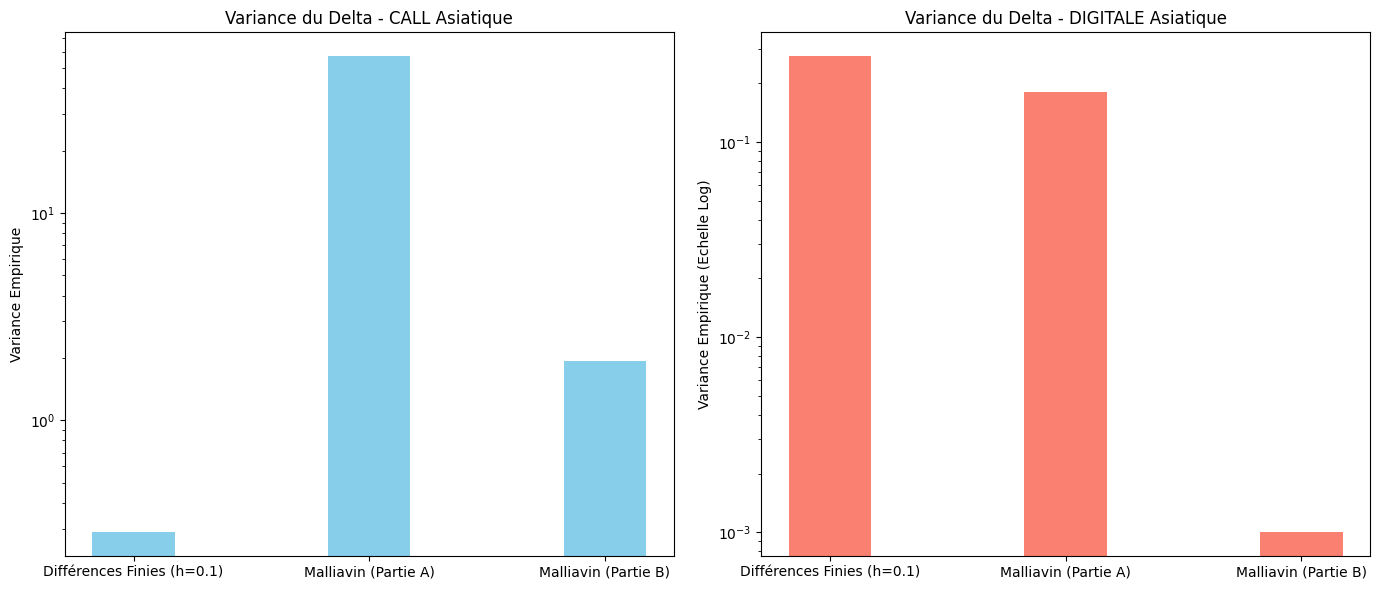

In [9]:
# Choix du paramètre h = 0.1 pour la DF dans la comparaison
h_comp = 0.1
var_call = [res_df[h_comp]['call_var'], np.var(delta_ca, ddof=1), np.var(delta_cb, ddof=1)]
var_dig = [res_df[h_comp]['dig_var'], np.var(delta_da, ddof=1), np.var(delta_db, ddof=1)]

labels = ['Différences Finies (h=0.1)', 'Malliavin (Partie A)', 'Malliavin (Partie B)']


# Plotting
x_pos = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(14, 6))

# Call Asiatique
plt.subplot(1, 2, 1)
bars1 = plt.bar(x_pos, var_call, width, color='skyblue')
plt.ylabel('Variance Empirique')
plt.title('Variance du Delta - CALL Asiatique')
plt.xticks(x_pos, labels)
plt.yscale('log') 

# Digitale Asiatique
plt.subplot(1, 2, 2)
bars2 = plt.bar(x_pos, var_dig, width, color='salmon')
plt.ylabel('Variance Empirique (Echelle Log)')
plt.title('Variance du Delta - DIGITALE Asiatique')
plt.xticks(x_pos, labels)
plt.yscale('log') # Echelle log car DF explose pour la digitale

plt.tight_layout()
plt.show()

### Question e

L'implémentation met parfaitement en évidence la force principale du Calcul de Malliavin pour le pricing de sensibilités en finance.

- Lorsque le payoff est régulier (comme le Call), la méthode historique des différences finies (surtout avec des variables communes) reste extrêmement performante et fournit les variances les plus faibles. La méthode B de Malliavin, en intégrant sur tout le chemin, est également tout à fait satisfaisante. La méthode A, en revanche, concentre tout le bruit sur le premier pas de temps très court, causant une variance rédhibitoire.

- Lorsque le payoff est singulier ou discontinu (comme la Digitale), la méthode des Différences Finies montre ses graves limites. Dès qu'on rend $h$ petit pour annuler le biais, la variance de la méthode diverge vers l'infini, l'estimateur devenant inutilisable en pratique. À l'inverse, les méthodes basées sur Malliavin ignorent mathématiquement la discontinuité du payoff en transférant la dérivation directement sur la dynamique de l'actif sous-jacent. Elles garantissent ainsi une variance maîtrisée et un calcul des "Grecs" parfaitement robuste. La Méthode B se révèle ici être le compromis ultime par sa stabilité.